# Topic analysis 

This notebook implements the analysis of the topics identified in the comments. 

In [1]:
import pandas as pd
import numpy as np
import math

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

from collections import Counter

from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

from umap import UMAP

from database.comments import Comments
from database.topics import Topics

import sys
sys.path.append('../functions')
from nlp_tasks import NLP_Tasks
from elastic_search_fncs import ElasticSearchFncs
import preprocessing_fncs as ppf

nlp_tasks = NLP_Tasks()
esf = ElasticSearchFncs()

cs = Comments(env="dev")
tp = Topics(env='dev')

/opt/miniconda3/envs/nlp_env_analysis/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use mps:0
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use mps:0


Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.
Connecting to the ai4ci-db-dev database...
Successfully connected to ai4ci-db-dev.


### Read in the .csv with the topic names and representations 

In [2]:
topic_names = pd.read_csv('../model_outputs/topic_model/bertopic_less_topics/object_topics.csv')
topic_names.head()

,Topic,Count,Name,Representation,MaximalMarginalRelevance,KeyBERTInspired,Representative_Docs,doc_1,doc_2,doc_3
0,-1,38355,-1_the_to_and_of,"['the', 'to', 'and', 'of', 'this', 'is', 'in',...","['the', 'to', 'and', 'of', 'this', 'is', 'in',...","['parking', 'space', 'traffic', 'road', 'impac...",['i object to this proposal on several grounds...,i object to this proposal on several grounds. ...,"firstly, i have been very concerned by the beh...",residents of are already surrounded on two sid...
1,0,14746,0_object_planning_application_following,"['object', 'planning', 'application', 'followi...","['object', 'planning', 'application', 'followi...","['objection', 'following', 'reasons', 'applica...",['i strongly object to this proposal for the f...,i strongly object to this proposal for the fol...,i strongly object to this proposal for the fol...,i strongly object to this proposal for the fol...
2,1,7481,1_trees_garden_green_space,"['trees', 'garden', 'green', 'space', 'of', 't...","['trees', 'garden', 'green', 'space', 'of', 't...","['garden', 'trees', 'greenery', 'tree', 'natur...","['there is no space for a garden.', 'this deve...",there is no space for a garden.,this development is also contrary to the londo...,loss of garden / green space :
3,2,7004,2_parking_traffic_car_already,"['parking', 'traffic', 'car', 'already', 'tran...","['parking', 'traffic', 'car', 'already', 'tran...","['parking', 'car', 'traffic', 'bus', 'parked',...","['2. traffic and parking :', '4. parking', 'pa...",2. traffic and parking :,4. parking,parking :
4,3,6644,3_character_design_out_of,"['character', 'design', 'out', 'of', 'keeping'...","['character', 'design', 'out', 'of', 'keeping'...","['design', 'character', 'appearance', 'style',...","['out of keeping with character of area', 'the...",out of keeping with character of area,the proposal would be out of keeping with the ...,design and character


### Read in the topic dataframe with comments and topic assignments 

In [3]:
tp_df = tp.read_all()
tp_df.head()

,id,comment_id,topic_number,probability,add_date
0,1,230384FUL_16,[],[],2025-10-21
1,2,21/3676/FUL_537,"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]",2025-10-21
2,3,21/03147/FUL_6,"[19, 0, 25]","[0.7651527090417625, 0.5496195083521116, 0.155...",2025-10-21
3,4,230384FUL_22,[47],[1.0],2025-10-21
4,5,230384FUL_15,[2],[1.0],2025-10-21


In [4]:
# 'junk' topics - those that don't provide useful information for th purpose of this analysis
bad_topics = {"bad":[-1,0,10,16,31,39,41,42,56,57,88,98]}

# topics that are similar enough to be grouped together
same_topics = {"garden space":[1,43],
               "parking":[2,7,47], 
               "out of character":[3,36,40], 
               "too tall":[5,33],
               "conservation area":[8,35,48],
               "noise pollution":[11,38,46,49],
               "overdevelopment":[13,25],
               "traffic congestion":[18, 21]}

### Simplify the topics 

Simplify the topic assignment as follows:
1. Remove topics whose topic number is >= 50. This reduces the number of topics. 
2. Remove topics in 'bad_topics'. These are the topics which aren't useful for the analysis - i.e. they have clustered based on the word 'objection' or 'thank you' - it doesn't include material information. 
3. Merge similar topics in 'same_topics'. These are topics I have manually identified as being largely undifferentiated. 

In [5]:
# Build a reverse mapping from each old topic to representative topic
topic_map = {}
for _, nums in same_topics.items():
    main = nums[0]
    for n in nums:
        topic_map[n] = main

# Create new columns for updated topics and probabilities with empty lists
tp_df['topic_number_updated'] = [[] for _ in range(len(tp_df))]
tp_df['probability_updated'] = [[] for _ in range(len(tp_df))]

# Process each row to filter and merge topics
for i in range(len(tp_df)):
    topics = tp_df.at[i, 'topic_number']
    probs = tp_df.at[i, 'probability']

    # filter out topics >= 50
    filtered = [(t, p) for t, p in zip(topics, probs) if t < 50]

    # filter out topics in bad_topics
    filtered = [(t, p) for t, p in filtered if all(t not in v for v in bad_topics.values())]

    # merge topics in same_topics
    merged = {}
    for t, p in filtered:
        new_t = topic_map.get(t, t)  # replace with main topic if part of a group
        merged[new_t] = merged.get(new_t, 0) + p  # sum probabilities

    # store results
    tp_df.at[i, 'topic_number_updated'] = list(merged.keys())
    tp_df.at[i, 'probability_updated'] = list(merged.values())


In [6]:
tp_df.head()

,id,comment_id,topic_number,probability,add_date,topic_number_updated,probability_updated
0,1,230384FUL_16,[],[],2025-10-21,[],[]
1,2,21/3676/FUL_537,"[16, 0, 7]","[0.9496124818197162, 1.0, 0.532771282582039]",2025-10-21,[2],[0.532771282582039]
2,3,21/03147/FUL_6,"[19, 0, 25]","[0.7651527090417625, 0.5496195083521116, 0.155...",2025-10-21,"[19, 13]","[0.7651527090417625, 0.1552818674969217]"
3,4,230384FUL_22,[47],[1.0],2025-10-21,[2],[1.0]
4,5,230384FUL_15,[2],[1.0],2025-10-21,[2],[1.0]


### Create a mapping between the topic number and topic names 

In [7]:
# create dictionary mapping topic number to name
topic_dict = dict(zip(topic_names['Topic'], topic_names['Name']))

# reduce to only include topics present in the updated topic/comment dataframe
unique_topics = set()
for topics in tp_df['topic_number_updated']:
    unique_topics.update(topics)

filtered_topic_dict = {k: v for k, v in topic_dict.items() if k in unique_topics}

# remove number and underscores from topic names
for k in filtered_topic_dict:
    name = filtered_topic_dict[k]
    name = name.split('_', 1)[1] if '_' in name else name
    name = name.replace('_', ' ')
    filtered_topic_dict[k] = name

In [8]:
# Flatten topics and count frequencies in the topic/common dataframe
all_topics = [t for topics in tp_df['topic_number_updated'] for t in topics]
topic_counts = Counter(all_topics)

# Sort by frequency (descending)
topic_counts = dict(sorted(topic_counts.items(), key=lambda x: x[1], reverse=True))

### Create hex colour mapping for the topics 

In [ ]:
custom_hex_colors = [
    "#336589", "#aad874", "#fba337", "#b63838", "#a373d0",
    "#865349", "#F2F527", "#494A2A", "#df51b4", "#7d6565", 
    "#1cc6d9", "#453D70", "#bcbd22", "#09A31B", "#91e0b0",
    "#a1c7e3", "#d1e7c3", "#e3d1bc", "#b48989", "#4e0f88",
    "#D12E0E", "#B4B489", "#EDEEE0", "#df9fcc", "#e58888", 
    "#a8dadf", "#7A6CC8", "#A7A70A", "#A1D6A7", "#27c968"
]

# map custom_hex_colors to topics in filtered_topic_dict
color_map = {topic: custom_hex_colors[i % len(custom_hex_colors)]
             for i, topic in enumerate(filtered_topic_dict.values())}

### Simplify the topic names

Dictionary mapping the topic representations generated by BERTopic to simplified names for the sake of analysis/plotting. 

In [10]:
x_label_map = {'parking traffic car already':'loss of parking',
 'trees garden green space':'loss of gardens',
 'character design out of':'out of character',
 'height scale buildings tall':'too tall',
 'noise disruption pollution will':'noise pollution',
 'light sunlight daylight loss':'loss of light',
 'density overdevelopment overcrowding dense':'overdevelopment',
 'amenity impact on of':'impact on amenities',
 'conservation heritage listed area':'heritage area',
 'family bedroom housing social':'wrong housing type',
 'privacy overlooking loss windows':'loss of privacy',
 'congested parking already traffic':'traffic congestion',
 'safety dangerous traffic fire':'unsafe',
 'bin refuse storage bins':'lack of bins',
 'height light privacy of':'too tall, loss of light',
 'environment wildlife biodiversity local': 'loss of wildlife',
 'water drainage flooding flood': 'flood risk',
 'view from the my': 'loss of view',
 'consultation engagement process been': 'insufficent community enagement',
 'impact parking on amenity': 'parking and amenity impact',
 'dust pollution air noise': 'air pollution',
 'business shop retail shops': 'impact on retail',
 'affordable housing homes rent': 'not affordable',
 'ugly eyesore visual an': 'eyesore',
 'disabled parking elderly accessible': 'lack of disabled parking',
 'parking character is traffic': 'parking and traffic',
 'carbon climate sustainable energy': 'not environmentally sustainable',
 'park green space trees': 'loss of parks',
 'value of community the': 'bad for community',
 'rent dwelling bed viability': 'rental properties'
}

### Plot barchart of top topics with frequency 

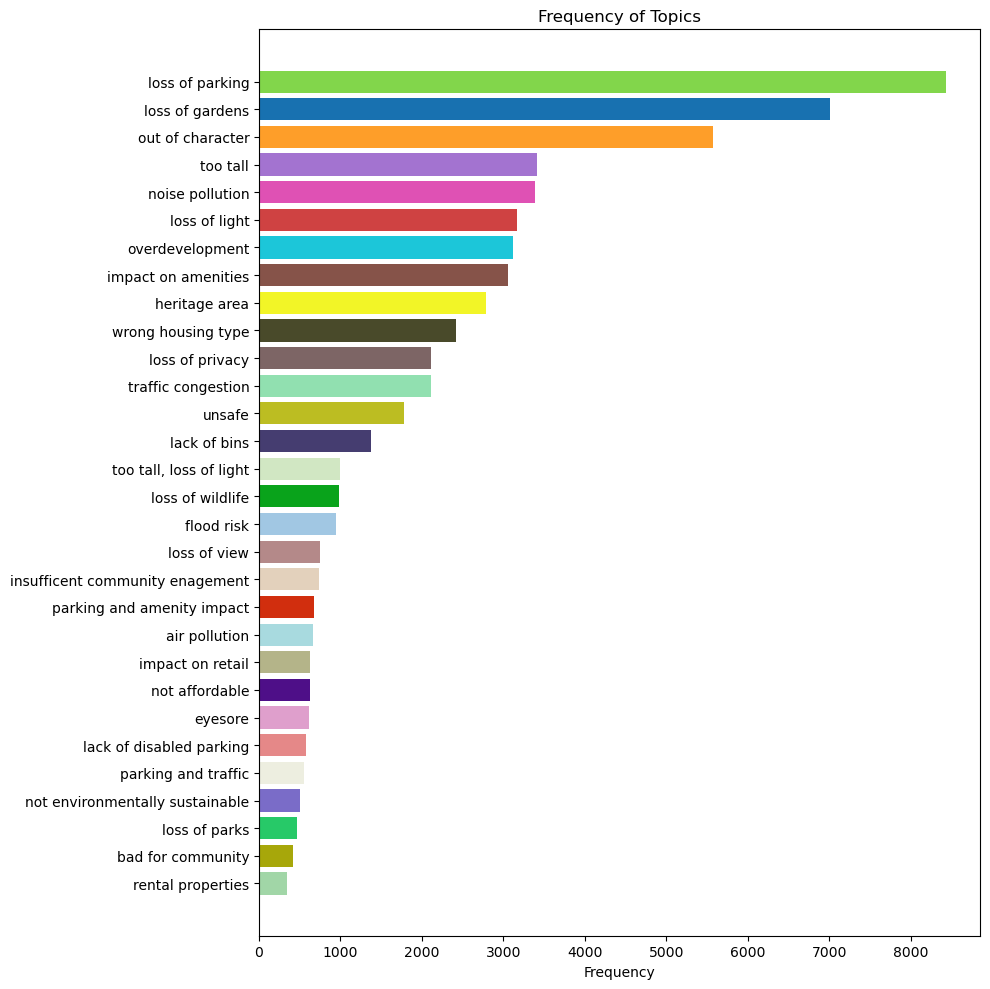

In [11]:
# Convert to parallel lists for plotting (categorical x-axis)
x_labels = [filtered_topic_dict[k] for k in topic_counts.keys()]
y_values = list(topic_counts.values())

bar_colors = [color_map[topic] for topic in x_labels]

new_x_labels = [x_label_map.get(label, label) for label in x_labels]

plt.figure(figsize=(10, 10))
plt.barh(new_x_labels, y_values, color=bar_colors)

plt.gca().invert_yaxis()
plt.xlabel('Frequency')
plt.title('Frequency of Topics')

plt.tight_layout()
plt.savefig('../results/figures/object_topics_frequency.png', dpi=500)

plt.show()

In [12]:
# print frequency table of topics
freq_table = pd.DataFrame({
    'Topic': new_x_labels,
    'Frequency': y_values
})
# add a column with percentage
freq_table['Percentage'] = (freq_table['Frequency'] / freq_table['Frequency'].sum()) * 100
freq_table


,Topic,Frequency,Percentage
0,loss of parking,8427,14.001595
1,loss of gardens,7007,11.642242
2,out of character,5576,9.264613
3,too tall,3418,5.679062
4,noise pollution,3386,5.625893
5,loss of light,3161,5.252052
6,overdevelopment,3115,5.175622
7,impact on amenities,3051,5.069285
8,heritage area,2785,4.627322
9,wrong housing type,2412,4.007577


## Match and merge topics to comments 

Analyse the topics at the individual comment level. 

In [13]:
cs_df = cs.read_all()

df = pd.merge(cs_df, tp_df[['comment_id', 'topic_number_updated', 'probability_updated']], on='comment_id', how='left')

In [14]:
df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score,topic_number_updated,probability_updated
0,86049,Barnet,21/2810/FUL_2,21/2810/FUL,"6 Tangmere Way London, United Kingdom NW9 5WW",Objects,2021-06-22,some residents in Gaydon lane have raised conc...,2025-04-10,51.599700,-0.248590,some residents in have raised concerns about t...,E09000003,-0.084598,"[4, 1]","[0.12988809899513143, 1.0]"
1,78219,Barnet,24/3762/FUL_36,24/3762/FUL,88 Westbury Road London N12 7PD,Objects,2024-10-02,I am writing to express my strong objection to...,2025-04-08,51.612910,-0.189180,I am writing to express my strong objection to...,E09000003,-0.362558,"[1, 3, 13, 5, 12, 11, 2, 6, 4, 19, 32, 37]","[0.10169287038113313, 0.45852829355375246, 1.0..."
2,86056,Barnet,21/2810/FUL_9,21/2810/FUL,1 Gaydon Lane Colindale London NW9 5WA,Objects,2021-06-20,"1. From the plans and elevations, the proposed...",2025-04-10,51.601675,-0.252985,"1. From the plans and elevations, the proposed...",E09000003,-0.424556,"[9, 18, 1]","[0.07262465521835984, 1.0, 1.0]"
3,86065,Barnet,21/2810/FUL_18,21/2810/FUL,7 Elvington Lane London nw9 5wb,Objects,2021-06-08,we dont want this houses at the bottom of our ...,2025-04-10,51.602100,-0.252440,we dont want this houses at the bottom of our ...,E09000003,-0.365758,"[9, 1, 2]","[1.0, 0.4683139824985618, 0.31925777380040804]"
4,86321,Brent,22/1280_1,22/1280,"69 Crundale Avenue, London, NW9 9PJ",Neutral,2022-05-11,I am not objecting to this planning applicatio...,2025-04-10,51.584920,-0.276780,I am not objecting to this planning applicatio...,E09000005,0.019409,"[6, 27, 28, 11, 8, 3, 20, 32]","[0.2397917702597925, 0.8024043239506696, 0.290..."


In [15]:
# make sure 'topic_number_updated' and 'probability_updated' are lists
df['topic_number_updated'] = df['topic_number_updated'].apply(lambda x: x if isinstance(x, list) else [])
df['probability_updated'] = df['probability_updated'].apply(lambda x: x if isinstance(x, list) else [])

# make sure 'topic_number_updated' are integers
df['topic_number_updated'] = df['topic_number_updated'].apply(lambda lst: [int(i) for i in lst])

# run ppfrocessing format_df function
df = ppf.format_df(df, borough_col_name='council')

### Plot barchart of topic frequency by council 

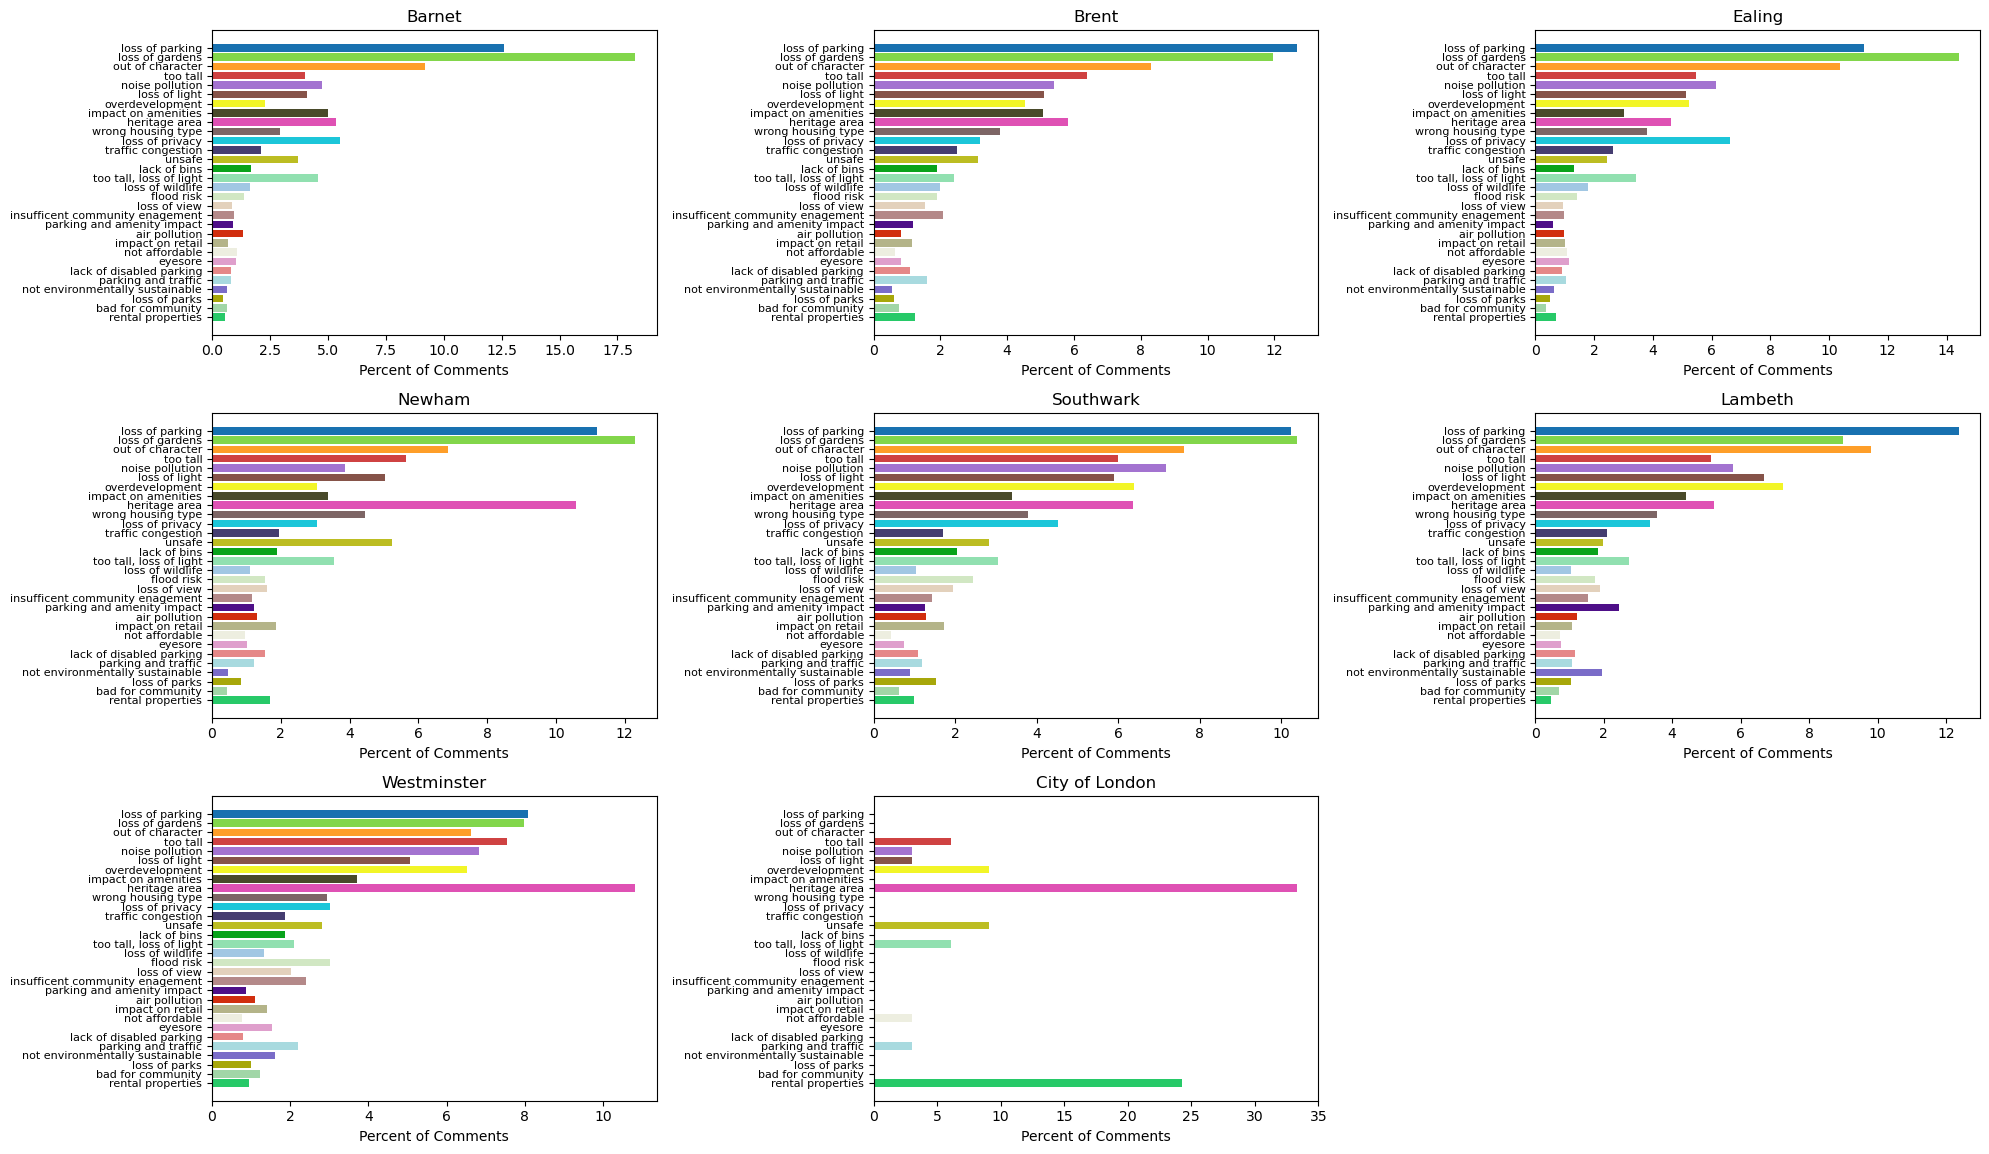

In [ ]:
councils = df['council'].unique()

# Ordered topic IDs (numeric keys)
ordered_topic_ids = list(filtered_topic_dict.keys())

# Color map keyed by topic ID
color_map = {
    topic_id: custom_hex_colors[i % len(custom_hex_colors)]
    for i, topic_id in enumerate(ordered_topic_ids)
}

# Create subplot grid
num_councils = len(councils)
cols = 3
rows = math.ceil(num_councils / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for ax, council in zip(axes, councils):
    council_df = df[df['council'] == council]

    # Flatten topics into a list of numeric IDs
    all_topics = [t for topics in council_df['topic_number_updated'] for t in topics]

    # Count frequencies
    topic_counts = Counter(all_topics)
    total_comments = sum(topic_counts.values())

    # Percent of total
    y_values = [
        (topic_counts.get(topic_id, 0) / total_comments) * 100 if total_comments > 0 else 0
        for topic_id in ordered_topic_ids
    ]

    x_labels = [filtered_topic_dict[tid] for tid in ordered_topic_ids]
    bar_colors = [color_map[tid] for tid in ordered_topic_ids]

    ax.barh(new_x_labels, y_values, color=bar_colors)
    ax.set_title(council)
    ax.invert_yaxis()
    ax.set_xlabel('Percent of Comments')
    ax.tick_params(axis='y', labelsize=8)

# Hide any empty subplot panels
for i in range(len(councils), len(axes)):
    fig.delaxes(axes[i])

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


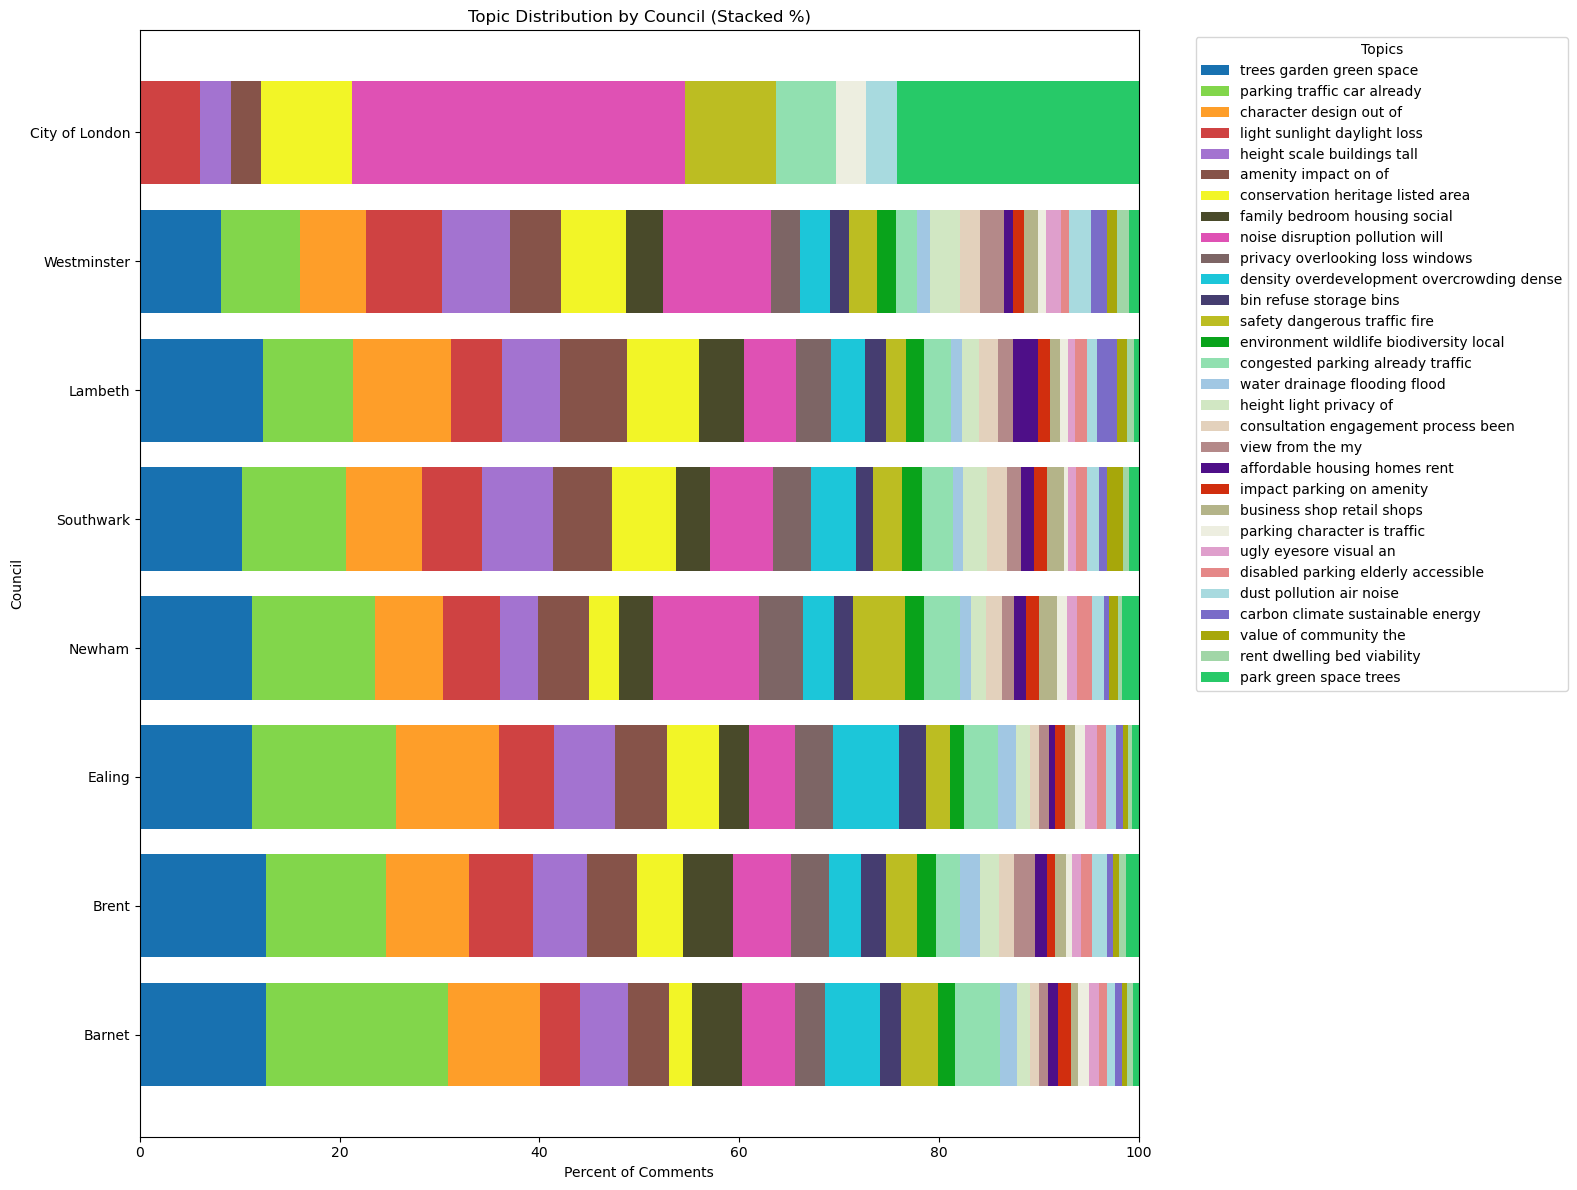

In [38]:
councils = df['council'].dropna().unique()

# Ordered topic IDs
ordered_topic_ids = list(filtered_topic_dict.keys())

# Topic colour map
color_map = {
    topic_id: custom_hex_colors[i % len(custom_hex_colors)]
    for i, topic_id in enumerate(ordered_topic_ids)
}

# Build a matrix: each row = council, each column = topic % share
data = []

for c in councils:
    council_df = df[df['council'] == c]

    # Flatten topics
    all_topics = [t for topics in council_df['topic_number_updated'] for t in topics]

    topic_counts = Counter(all_topics)
    total_comments = sum(topic_counts.values())

    percents = [
        (topic_counts.get(topic_id, 0) / total_comments) * 100 if total_comments > 0 else 0
        for topic_id in ordered_topic_ids
    ]

    data.append(percents)

# Put into a DataFrame: rows=councils, columns=topics
data = pd.DataFrame(data, columns=ordered_topic_ids, index=councils)

# ---- Plot ----

fig, ax = plt.subplots(figsize=(16, 12))

left = [0] * len(councils)

for tid in ordered_topic_ids:
    ax.barh(
        y=councils,
        width=data[tid],
        left=left,
        color=color_map[tid],
        label=filtered_topic_dict[tid]
    )
    left = [l + w for l, w in zip(left, data[tid])]

ax.set_xlabel("Percent of Comments")
ax.set_ylabel("Council")
ax.set_title("Topic Distribution by Council (Stacked %)")
ax.set_xlim(0, 100)

# Legend placed outside the plot
ax.legend(
    title="Topics",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


## Get planning df 

In [17]:
esf = ElasticSearchFncs()
esf.check_connection()
pld_df = esf.res_units_x_query(min_res_units=1, since_year="01/01/2021", to_year="01/05/2025")
# Run the formatting functions on pld_df
pld_df = ppf.format_df(pld_df)
# Add column for hosuing type - based on logic regarding number of residential units
pld_df = ppf.add_housing_type(pld_df)

Connected to Elastic Search


In [18]:
pld_df.head()

,lpa_name,uprn,actual_completion_date,decision,pp_id,postcode,wgs84_polygon.coordinates,wgs84_polygon.type,affordable_housing_fast_track,total_no_proposed_residential_units_shared_equity,...,total_no_affordable_units,polygon.crs.type,polygon.crs.properties.name,self_build,social_housing,affordable_rent,affordable_sale,market_rent,market_sale,housing_type
0,Haringey,100021221922,NaT,None,PP-13292547,N6 4JS,"[[[-0.163738, 51.574545], [-0.163739, 51.57451...",Polygon,False,0,...,NaN,NaN,NaN,0,0,0,0,0,1,Market housing
1,Greenwich,100021014360,NaT,None,PP-13747531,None,"[[[0.0824158, 51.4845463], [0.0825110999999999...",Polygon,False,0,...,NaN,NaN,NaN,0,0,0,0,1,0,Market housing
2,Hounslow,None,NaT,None,PP-13731978,None,"[[[-0.244991, 51.497727], [-0.245034, 51.49761...",Polygon,NaN,0,...,NaN,NaN,NaN,0,0,0,0,0,15,Market housing
3,Greenwich,100020988708,NaT,None,PP-13833559,None,NaN,NaN,False,0,...,NaN,NaN,NaN,0,0,0,0,1,0,Market housing
4,Islington,5300066661,NaT,None,PP-13739548,None,"[[[-0.084176, 51.551896], [-0.084177, 51.55186...",Polygon,NaN,0,...,NaN,NaN,NaN,0,0,0,0,1,0,Market housing


In [19]:
pld_df = ppf.create_decision_outcomes(pld_df, completion_date_col_name='decision_date')

In [20]:
pld_df.head()

,lpa_name,uprn,actual_completion_date,decision,pp_id,postcode,wgs84_polygon.coordinates,wgs84_polygon.type,affordable_housing_fast_track,total_no_proposed_residential_units_shared_equity,...,polygon.crs.type,polygon.crs.properties.name,self_build,social_housing,affordable_rent,affordable_sale,market_rent,market_sale,housing_type,outcome
0,Haringey,100021221922,NaT,None,PP-13292547,N6 4JS,"[[[-0.163738, 51.574545], [-0.163739, 51.57451...",Polygon,False,0,...,NaN,NaN,0,0,0,0,0,1,Market housing,Other
1,Greenwich,100021014360,NaT,None,PP-13747531,None,"[[[0.0824158, 51.4845463], [0.0825110999999999...",Polygon,False,0,...,NaN,NaN,0,0,0,0,1,0,Market housing,Other
2,Hounslow,None,NaT,None,PP-13731978,None,"[[[-0.244991, 51.497727], [-0.245034, 51.49761...",Polygon,NaN,0,...,NaN,NaN,0,0,0,0,0,15,Market housing,Other
3,Greenwich,100020988708,NaT,None,PP-13833559,None,NaN,NaN,False,0,...,NaN,NaN,0,0,0,0,1,0,Market housing,Other
4,Islington,5300066661,NaT,None,PP-13739548,None,"[[[-0.084176, 51.551896], [-0.084177, 51.55186...",Polygon,NaN,0,...,NaN,NaN,0,0,0,0,1,0,Market housing,Ongoing


In [21]:
pld_df.columns

Index(['lpa_name', 'uprn', 'actual_completion_date', 'decision', 'pp_id',
       'postcode', 'wgs84_polygon.coordinates', 'wgs84_polygon.type',
       'affordable_housing_fast_track',
       'total_no_proposed_residential_units_shared_equity',
       'total_no_proposed_residential_units_london_living_rent',
       'total_no_proposed_residential_units',
       'total_no_proposed_residential_units_social_rent',
       'total_no_proposed_residential_units_discount_market_sale',
       'total_no_proposed_residential_units_discount_market_rent_charged_at_london_rents',
       'total_no_proposed_residential_units_starter_homes',
       'total_no_proposed_residential_units_london_affordable_rent',
       'total_no_proposed_residential_units_market_for_rent',
       'total_no_proposed_residential_units_discount_market_rent',
       'total_no_proposed_residential_units_intermediate',
       'total_no_proposed_residential_units_london_shared_ownership',
       'total_no_proposed_residential_unit

In [22]:
df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score,topic_number_updated,probability_updated
0,86049,Barnet,21/2810/FUL_2,21/2810/FUL,"6 Tangmere Way London, United Kingdom NW9 5WW",Objects,2021-06-22,some residents in Gaydon lane have raised conc...,2025-04-10,51.599700,-0.248590,some residents in have raised concerns about t...,E09000003,-0.084598,"[4, 1]","[0.12988809899513143, 1.0]"
1,78219,Barnet,24/3762/FUL_36,24/3762/FUL,88 Westbury Road London N12 7PD,Objects,2024-10-02,I am writing to express my strong objection to...,2025-04-08,51.612910,-0.189180,I am writing to express my strong objection to...,E09000003,-0.362558,"[1, 3, 13, 5, 12, 11, 2, 6, 4, 19, 32, 37]","[0.10169287038113313, 0.45852829355375246, 1.0..."
2,86056,Barnet,21/2810/FUL_9,21/2810/FUL,1 Gaydon Lane Colindale London NW9 5WA,Objects,2021-06-20,"1. From the plans and elevations, the proposed...",2025-04-10,51.601675,-0.252985,"1. From the plans and elevations, the proposed...",E09000003,-0.424556,"[9, 18, 1]","[0.07262465521835984, 1.0, 1.0]"
3,86065,Barnet,21/2810/FUL_18,21/2810/FUL,7 Elvington Lane London nw9 5wb,Objects,2021-06-08,we dont want this houses at the bottom of our ...,2025-04-10,51.602100,-0.252440,we dont want this houses at the bottom of our ...,E09000003,-0.365758,"[9, 1, 2]","[1.0, 0.4683139824985618, 0.31925777380040804]"
4,86321,Brent,22/1280_1,22/1280,"69 Crundale Avenue, London, NW9 9PJ",Neutral,2022-05-11,I am not objecting to this planning applicatio...,2025-04-10,51.584920,-0.276780,I am not objecting to this planning applicatio...,E09000005,0.019409,"[6, 27, 28, 11, 8, 3, 20, 32]","[0.2397917702597925, 0.8024043239506696, 0.290..."


In [23]:
pld_df['lpa_app_no_borough'] = pld_df['lpa_app_no'] + '_' + pld_df['borough']
df['lpa_app_no_borough'] = df['application_id'] + '_' + df['council']

In [24]:
df = pd.merge(df, pld_df[['lpa_app_no_borough', 'outcome', 'housing_type', 'total_no_proposed_residential_units']], left_on='lpa_app_no_borough', right_on='lpa_app_no_borough', how='left')

In [25]:
df

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,lon,cleaned_comment_text,lsoa_code,sentiment_score,topic_number_updated,probability_updated,lpa_app_no_borough,outcome,housing_type,total_no_proposed_residential_units
0,86049,Barnet,21/2810/FUL_2,21/2810/FUL,"6 Tangmere Way London, United Kingdom NW9 5WW",Objects,2021-06-22,some residents in Gaydon lane have raised conc...,2025-04-10,51.599700,-0.248590,some residents in have raised concerns about t...,E09000003,-0.084598,"[4, 1]","[0.12988809899513143, 1.0]",21/2810/FUL_Barnet,Permitted,Market housing,1.0
1,78219,Barnet,24/3762/FUL_36,24/3762/FUL,88 Westbury Road London N12 7PD,Objects,2024-10-02,I am writing to express my strong objection to...,2025-04-08,51.612910,-0.189180,I am writing to express my strong objection to...,E09000003,-0.362558,"[1, 3, 13, 5, 12, 11, 2, 6, 4, 19, 32, 37]","[0.10169287038113313, 0.45852829355375246, 1.0...",24/3762/FUL_Barnet,Permitted,Market housing,1.0
2,86056,Barnet,21/2810/FUL_9,21/2810/FUL,1 Gaydon Lane Colindale London NW9 5WA,Objects,2021-06-20,"1. From the plans and elevations, the proposed...",2025-04-10,51.601675,-0.252985,"1. From the plans and elevations, the proposed...",E09000003,-0.424556,"[9, 18, 1]","[0.07262465521835984, 1.0, 1.0]",21/2810/FUL_Barnet,Permitted,Market housing,1.0
3,86065,Barnet,21/2810/FUL_18,21/2810/FUL,7 Elvington Lane London nw9 5wb,Objects,2021-06-08,we dont want this houses at the bottom of our ...,2025-04-10,51.602100,-0.252440,we dont want this houses at the bottom of our ...,E09000003,-0.365758,"[9, 1, 2]","[1.0, 0.4683139824985618, 0.31925777380040804]",21/2810/FUL_Barnet,Permitted,Market housing,1.0
4,86321,Brent,22/1280_1,22/1280,"69 Crundale Avenue, London, NW9 9PJ",Neutral,2022-05-11,I am not objecting to this planning applicatio...,2025-04-10,51.584920,-0.276780,I am not objecting to this planning applicatio...,E09000005,0.019409,"[6, 27, 28, 11, 8, 3, 20, 32]","[0.2397917702597925, 0.8024043239506696, 0.290...",22/1280_Brent,Permitted,Market housing,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30419,86031,Barnet,21/2485/FUL_66,21/2485/FUL,5 Decoy Avenue London NW110ES,Objects,2021-06-09,I would like to object to the plans. I think t...,2025-04-10,51.586448,-0.204547,I would like to object to the plans. I think t...,E09000003,-0.677841,[2],[1.0],21/2485/FUL_Barnet,Permitted,Mixed affordable housing,64.0
30420,86027,Barnet,21/2485/FUL_62,21/2485/FUL,Cavendish House 155B Clapton Common London E5 9AE,Objects,2021-06-14,"Dear James,\n\nWe have received your letter ad...",2025-04-10,51.572803,-0.070573,"Dear ,\n\nWe have received your letter address...",E09000012,-0.242639,"[2, 3]","[1.4178001717316147, 1.0]",21/2485/FUL_Barnet,Permitted,Mixed affordable housing,64.0
30421,87534,Ealing,241002FUL_10,241002FUL,7 Thackeray Court Hanger Vale Lane London W53AT,Objects,2024-04-04,FROM Hanger Hill (Haymills) Estate Conservatio...,2025-04-10,51.500021,-0.192442,FROM () Estate Conservation Area Panel\n\nThe ...,E09000020,0.000000,"[5, 8]","[1.0, 0.23197881464450557]",241002FUL_Ealing,Permitted,Market housing,8.0
30422,88845,Barnet,22/0932/FUL_43,22/0932/FUL,36 Chesterfield Rd London N3 1PR,Objects,2022-03-27,This application has been rejected once before...,2025-04-10,51.611530,-0.192000,This application has been rejected once before...,E09000003,0.000000,[1],[1.0],22/0932/FUL_Barnet,Permitted,Social housing,1.0


## Plot the topics by build type 

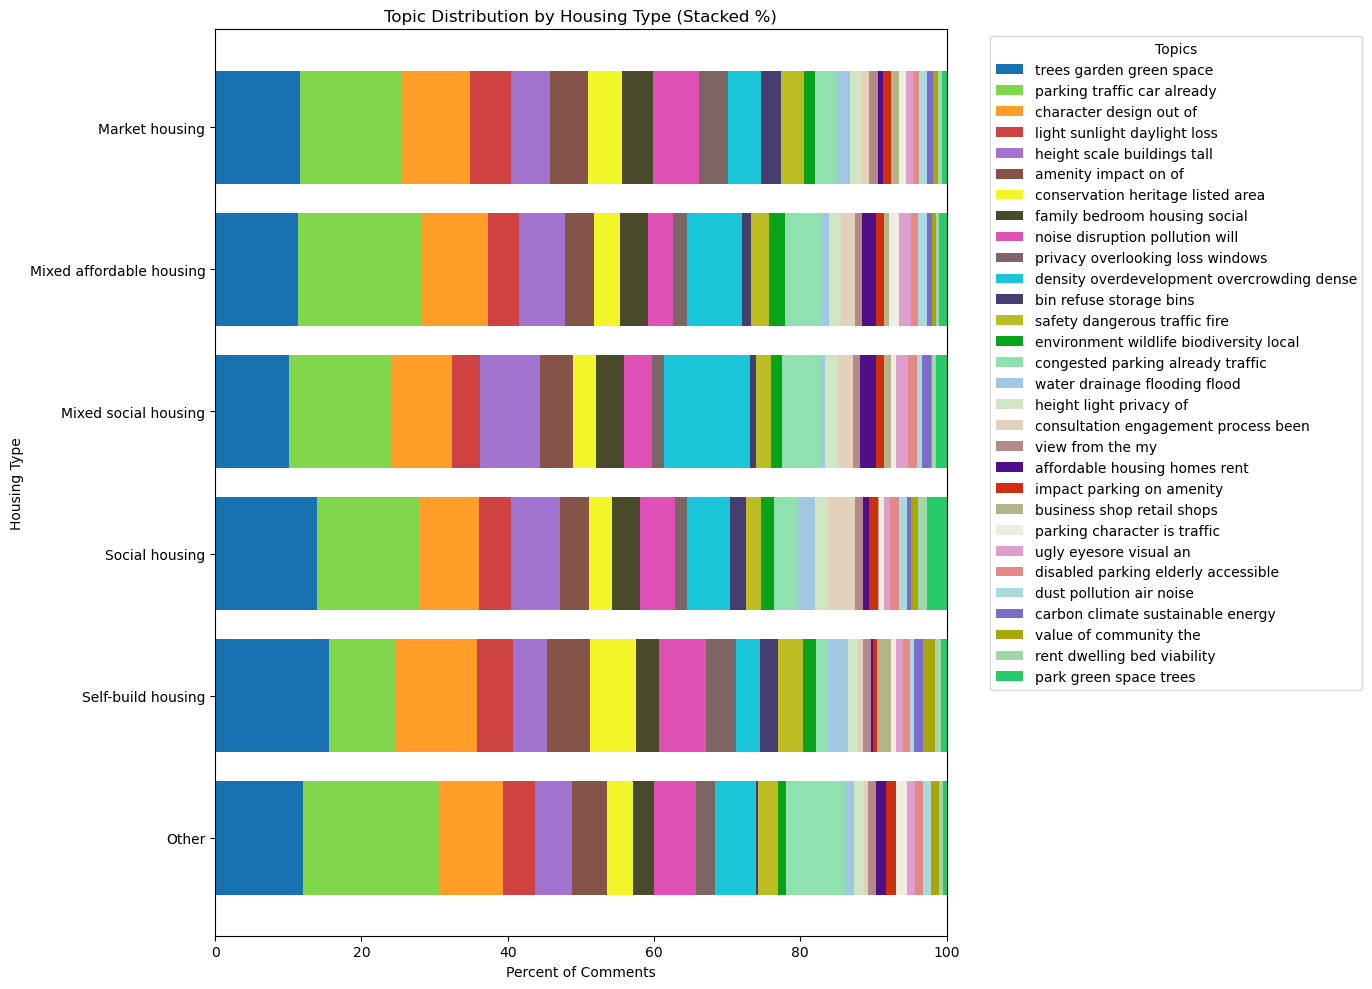

In [37]:
# Custom desired order
desired_order = [
    'Other',
    'Self-build housing',
    'Social housing',
    'Mixed social housing',
    'Mixed affordable housing',
    'Market housing'
]

house_types = df['housing_type'].dropna().unique()

# Keep only those that appear in your desired order
house_types = [ut for ut in desired_order if ut in house_types]

# Ordered topic IDs
ordered_topic_ids = list(filtered_topic_dict.keys())

# Color map keyed by topic ID
color_map = {
    topic_id: custom_hex_colors[i % len(custom_hex_colors)]
    for i, topic_id in enumerate(ordered_topic_ids)
}

# Prepare data matrix
data = []

for ht in house_types:
    house_df = df[df['housing_type'] == ht]

    # Flatten list of topics
    all_topics = [t for topics in house_df['topic_number_updated'] for t in topics]

    # Count frequencies
    topic_counts = Counter(all_topics)
    total_comments = sum(topic_counts.values())

    # Percent for each topic
    percents = [
        (topic_counts.get(topic_id, 0) / total_comments) * 100 if total_comments > 0 else 0
        for topic_id in ordered_topic_ids
    ]
    data.append(percents)

data = pd.DataFrame(data, columns=ordered_topic_ids, index=house_types)

# Reorder rows based on your preference:
data = data.loc[desired_order]
unit_types = data.index

# ---- Plot ----

fig, ax = plt.subplots(figsize=(14, 10))

left = [0] * len(house_types)

for tid in ordered_topic_ids:
    ax.barh(
        y=house_types,
        width=data[tid],
        left=left,
        color=color_map[tid],
        label=filtered_topic_dict[tid]
    )
    left = [l + w for l, w in zip(left, data[tid])]

ax.set_xlabel("Percent of Comments")
ax.set_ylabel("Housing Type")
ax.set_title("Topic Distribution by Housing Type (Stacked %)")
ax.set_xlim(0, 100)

# Legend outside the plot
ax.legend(
    title="Topics",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


## Plot the topics by the number of residential units 

In [28]:
# add column of category of residential build sizes 
def categorize_build_size(res_units):
    if pd.isna(res_units):
        return np.nan
    elif res_units == 1:
        return 'Single dwelling'
    elif 2 <= res_units <= 9:
        return 'Small (2-9 units)'
    elif 10 <= res_units <= 49:
        return 'Medium (10-49 units)'
    elif 50 <= res_units <= 199:
        return 'Large (10-49 units)'
    else:
        return 'Very large (200+ units)'

df['build_size_category'] = df['total_no_proposed_residential_units'].apply(categorize_build_size)

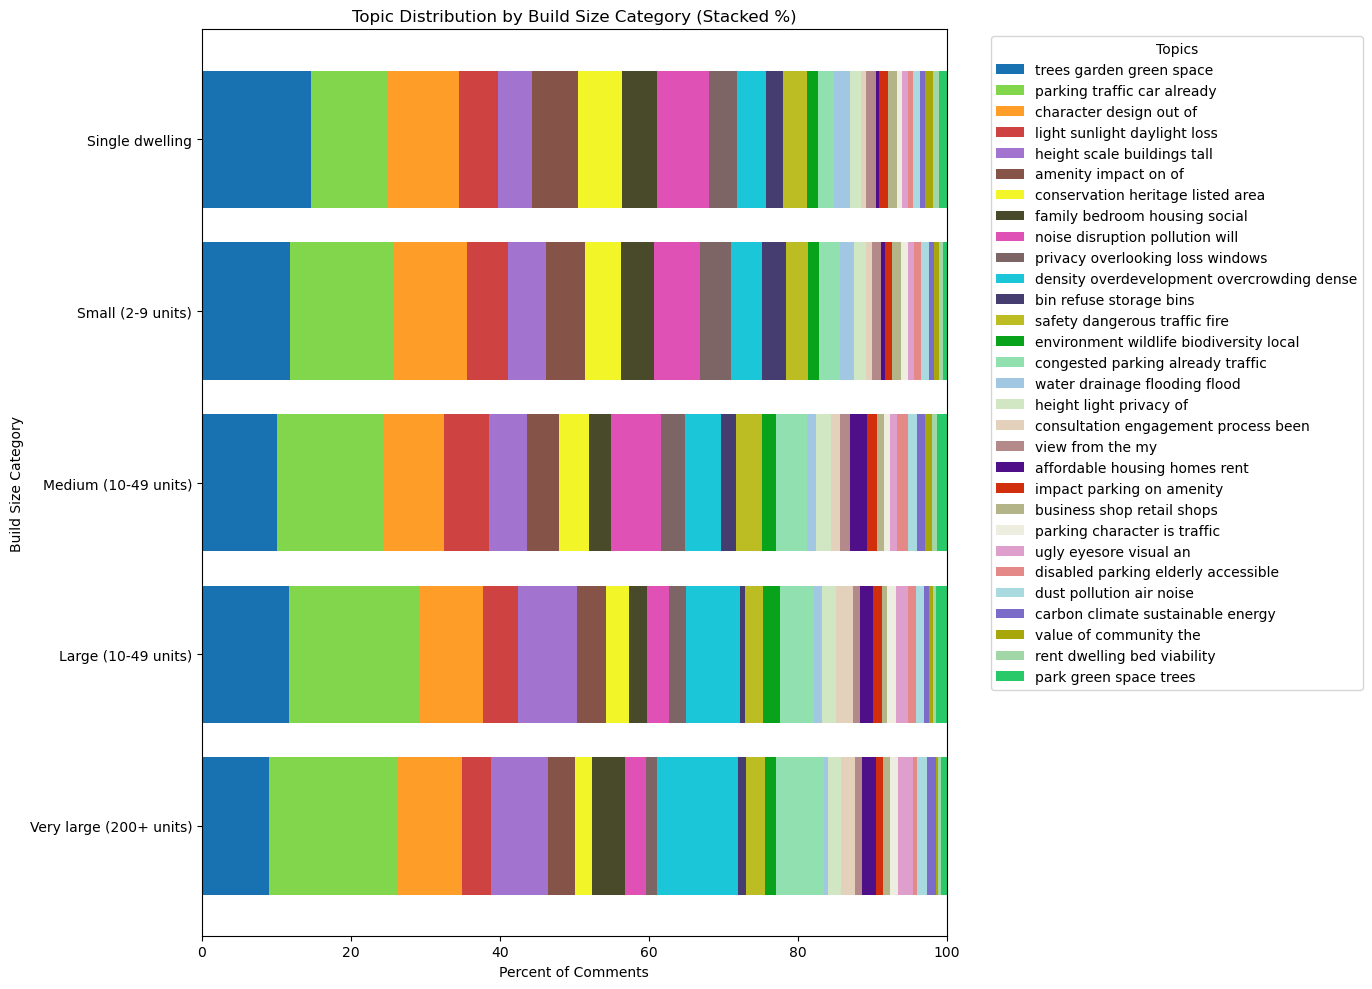

In [35]:
# Custom desired order
desired_order = [
    'Very large (200+ units)',
    'Large (10-49 units)',
    'Medium (10-49 units)',
    'Small (2-9 units)',
    'Single dwelling'   
]

# Unique types in your data (but we'll reorder them)
unit_types = df['build_size_category'].dropna().unique()

# Keep only those that appear in your desired order
unit_types = [ut for ut in desired_order if ut in unit_types]

# Ordered topic IDs
ordered_topic_ids = list(filtered_topic_dict.keys())

# Color map
color_map = {
    topic_id: custom_hex_colors[i % len(custom_hex_colors)]
    for i, topic_id in enumerate(ordered_topic_ids)
}

# Build data matrix
data = []

for ut in unit_types:
    unit_df = df[df['build_size_category'] == ut]

    # Flatten topic lists
    all_topics = [t for topics in unit_df['topic_number_updated'] for t in topics]

    topic_counts = Counter(all_topics)
    total_comments = sum(topic_counts.values())

    percents = [
        (topic_counts.get(topic_id, 0) / total_comments) * 100 if total_comments > 0 else 0
        for topic_id in ordered_topic_ids
    ]

    data.append(percents)

data = pd.DataFrame(data, columns=ordered_topic_ids, index=unit_types)

# ---- Plot ----

fig, ax = plt.subplots(figsize=(14, 10))

left = [0] * len(unit_types)

for tid in ordered_topic_ids:
    ax.barh(
        y=unit_types,
        width=data[tid],
        left=left,
        color=color_map[tid],
        label=filtered_topic_dict[tid]
    )
    left = [l + w for l, w in zip(left, data[tid])]

ax.set_xlabel("Percent of Comments")
ax.set_ylabel("Build Size Category")
ax.set_title("Topic Distribution by Build Size Category (Stacked %)")
ax.set_xlim(0, 100)

# Legend outside
ax.legend(
    title="Topics",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


## Plot sentiment score for each topic 

In [39]:
df.head()

,id,council,comment_id,application_id,address,stance,date,comment_text,add_date,lat,...,cleaned_comment_text,lsoa_code,sentiment_score,topic_number_updated,probability_updated,lpa_app_no_borough,outcome,housing_type,total_no_proposed_residential_units,build_size_category
0,86049,Barnet,21/2810/FUL_2,21/2810/FUL,"6 Tangmere Way London, United Kingdom NW9 5WW",Objects,2021-06-22,some residents in Gaydon lane have raised conc...,2025-04-10,51.599700,...,some residents in have raised concerns about t...,E09000003,-0.084598,"[4, 1]","[0.12988809899513143, 1.0]",21/2810/FUL_Barnet,Permitted,Market housing,1.0,Single dwelling
1,78219,Barnet,24/3762/FUL_36,24/3762/FUL,88 Westbury Road London N12 7PD,Objects,2024-10-02,I am writing to express my strong objection to...,2025-04-08,51.612910,...,I am writing to express my strong objection to...,E09000003,-0.362558,"[1, 3, 13, 5, 12, 11, 2, 6, 4, 19, 32, 37]","[0.10169287038113313, 0.45852829355375246, 1.0...",24/3762/FUL_Barnet,Permitted,Market housing,1.0,Single dwelling
2,86056,Barnet,21/2810/FUL_9,21/2810/FUL,1 Gaydon Lane Colindale London NW9 5WA,Objects,2021-06-20,"1. From the plans and elevations, the proposed...",2025-04-10,51.601675,...,"1. From the plans and elevations, the proposed...",E09000003,-0.424556,"[9, 18, 1]","[0.07262465521835984, 1.0, 1.0]",21/2810/FUL_Barnet,Permitted,Market housing,1.0,Single dwelling
3,86065,Barnet,21/2810/FUL_18,21/2810/FUL,7 Elvington Lane London nw9 5wb,Objects,2021-06-08,we dont want this houses at the bottom of our ...,2025-04-10,51.602100,...,we dont want this houses at the bottom of our ...,E09000003,-0.365758,"[9, 1, 2]","[1.0, 0.4683139824985618, 0.31925777380040804]",21/2810/FUL_Barnet,Permitted,Market housing,1.0,Single dwelling
4,86321,Brent,22/1280_1,22/1280,"69 Crundale Avenue, London, NW9 9PJ",Neutral,2022-05-11,I am not objecting to this planning applicatio...,2025-04-10,51.584920,...,I am not objecting to this planning applicatio...,E09000005,0.019409,"[6, 27, 28, 11, 8, 3, 20, 32]","[0.2397917702597925, 0.8024043239506696, 0.290...",22/1280_Brent,Permitted,Market housing,6.0,Small (2-9 units)


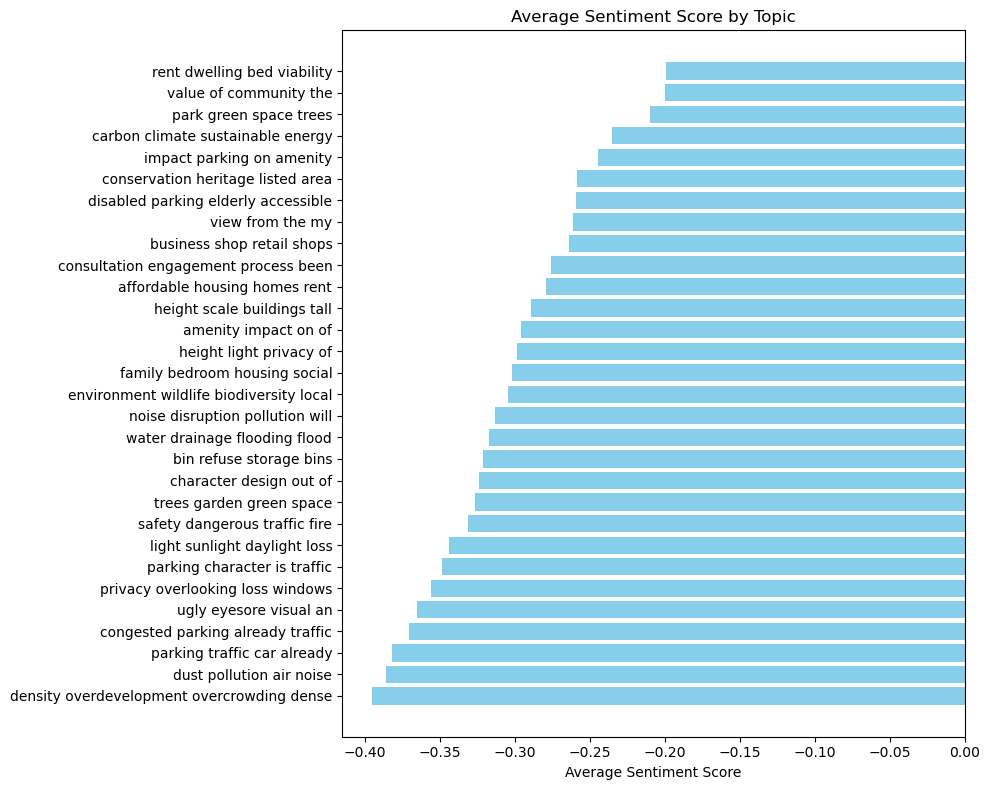

In [40]:
# for each topic get the average 'sentiment_score' of comments associated with that topic
topic_sentiments = {}
for index, row in df.iterrows():
    topics = row['topic_number_updated']
    sentiment = row['sentiment_score']
    
    for topic in topics:
        if topic not in topic_sentiments:
            topic_sentiments[topic] = []
        topic_sentiments[topic].append(sentiment)
    
# calculate average sentiment for each topic
avg_topic_sentiments = {topic: np.mean(sentiments) for topic, sentiments in topic_sentiments.items()}   

# create a dataframe for plotting
sentiment_df = pd.DataFrame({
    'Topic': [filtered_topic_dict[topic] for topic in avg_topic_sentiments.keys()],
    'Average Sentiment': list(avg_topic_sentiments.values())
})

# sort by average sentiment
sentiment_df = sentiment_df.sort_values(by='Average Sentiment', ascending=False)    
plt.figure(figsize=(10, 8))
plt.barh(sentiment_df['Topic'], sentiment_df['Average Sentiment'], color='skyblue')
plt.xlabel('Average Sentiment Score')
plt.title('Average Sentiment Score by Topic')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../results/figures/object_topics_average_sentiment.png', dpi=500)
plt.show()

## Plot the topic embedding for the documents 

In [31]:
sentence_model = SentenceTransformer("Bea-Taylor/objection_fine_tuned_4")
topic_model = BERTopic.load("../model_outputs/topic_model/bertopic_less_topics/full_model/object_model", embedding_model=sentence_model)

In [32]:
# Load the comments from the database
df = cs.read_all()

df_objects = df[df['stance']=='Objects']

### ppfrocess the text data

# split text on newlines, this function preserves the metadata by exploding the dataframe
df_objects_split = nlp_tasks.split_text_on_newline(df=df_objects, column='cleaned_comment_text')

print(f'\n Length after splitting data')
print('Objects:', len(df_objects_split))

# split the text by chunks of a maximum length, this function preserves the metadata by exploding the dataframe

max_length_tokens = sentence_model.get_max_seq_length()

df_objects_split = nlp_tasks.split_text_by_length(df=df_objects_split, column='cleaned_comment_text', max_length=max_length_tokens, overlap=40, filter_empty=False, filter_short=False)

print(f'\n Length after chunking data')
print('Objects:', len(df_objects_split))

cleaned_object_text = df_objects_split['cleaned_comment_text'].tolist()

Token indices sequence length is longer than the specified maximum sequence length for this model (286 > 256). Running this sequence through the model will result in indexing errors



 Length after splitting data
Objects: 140946


KeyboardInterrupt: 

In [ ]:
embeddings = sentence_model.encode(cleaned_object_text, show_progress_bar=True)
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)

Batches: 100%|██████████| 4437/4437 [07:08<00:00, 10.36it/s]


In [ ]:
topics = topic_model.get_document_info(cleaned_object_text)['Topic'].to_numpy()

Number of unique topics to plot: 30


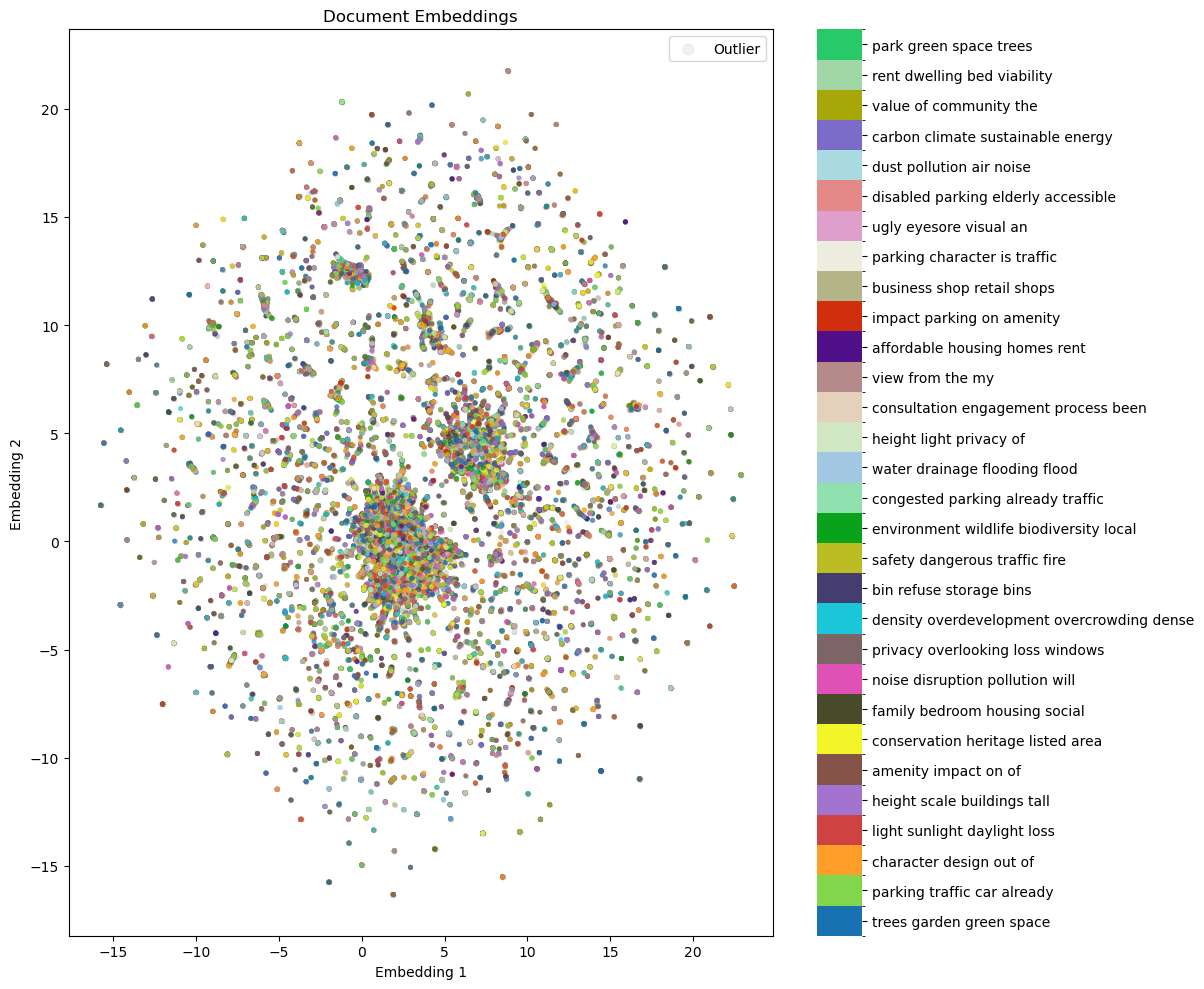

In [ ]:
# --- build reduced topic list ---
unique_topics = set()
for topic_list in tp_df['topic_number_updated']:
    unique_topics.update(topic_list)
unique_topics = sorted(unique_topics)

n_topics = len(unique_topics)

print(f'Number of unique topics to plot: {n_topics}')

# --- color palette ---
colors_for_topics = [custom_hex_colors[i % len(custom_hex_colors)] for i in range(n_topics)]
cmap = ListedColormap(colors_for_topics)
norm = BoundaryNorm(boundaries=np.arange(-0.5, n_topics + 0.5, 1), ncolors=n_topics)

# --- figure and axis ---
fig, ax = plt.subplots(figsize=(12, 10))

# ensure boolean masks are proper boolean NumPy arrays
is_outlier = (topics == -1)
is_reduced_topic = np.array([t in unique_topics for t in topics], dtype=bool)

# --- Plot outliers (gray) ---
ax.scatter(
    reduced_embeddings[is_outlier, 0],
    reduced_embeddings[is_outlier, 1],
    color='lightgrey',
    s=7,
    alpha=0.3,
    label='Outlier'
)

# --- Plot other topics (not in reduced list) in gray ---
ax.scatter(
    reduced_embeddings[~is_outlier & ~is_reduced_topic, 0],
    reduced_embeddings[~is_outlier & ~is_reduced_topic, 1],
    color='lightgray',
    s=7,
    alpha=0.3
)

# --- Plot points in your reduced topic list (colored) ---
ax.scatter(
    reduced_embeddings[~is_outlier & is_reduced_topic, 0],
    reduced_embeddings[~is_outlier & is_reduced_topic, 1],
    c=[unique_topics.index(t) for t in topics[~is_outlier & is_reduced_topic]],
    cmap=cmap,
    norm=norm,
    s=7,
    alpha=0.6
)



# --- Labels and layout ---
ax.set_title('Document Embeddings')
ax.set_xlabel('Embedding 1')
ax.set_ylabel('Embedding 2')

# --- Discrete colorbar for selected topics only ---
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, ticks=np.arange(n_topics))
cbar.ax.set_yticklabels([filtered_topic_dict.get(t, f'Topic {t}') for t in unique_topics])
cbar.outline.set_visible(False)

ax.legend(markerscale=3)
plt.tight_layout()

plt.savefig('../results/figures/object_topics_scatter.png', dpi=500)
plt.show()